In [43]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Convert the text into a Python list
lokmbub = json.load(open("lokMBUBDATA.json"))

# 3. Create the DataFrame
df = pd.DataFrame(lokmbub)

# 4. Save it so you never have to paste it again
#df.to_csv("lok_bias_data.csv", index=False)

print("Data saved! You have", len(df), "rows to analyze.")
print(df.columns)

Data saved! You have 60 rows to analyze.
Index(['id', 'date', 'source', 'headline', 'category', 'party_mentioned',
       'reported_sentiment', 'factual_accuracy_rating', 'bias_score'],
      dtype='object')


In [44]:
# Calculate the Average Bias Score per Source for each Party
bias_matrix = df.groupby(['source', 'party_mentioned'])['bias_score'].mean().unstack()

In [45]:
print("--- Media Bias Matrix ---")
print(bias_matrix)

--- Media Bias Matrix ---
party_mentioned                      BJP    INC
source                                         
Daily Bharat                     0.43000 -0.850
The Capital Post                 0.43750 -0.850
The Global Times (Hypothetical)  0.44375 -0.875


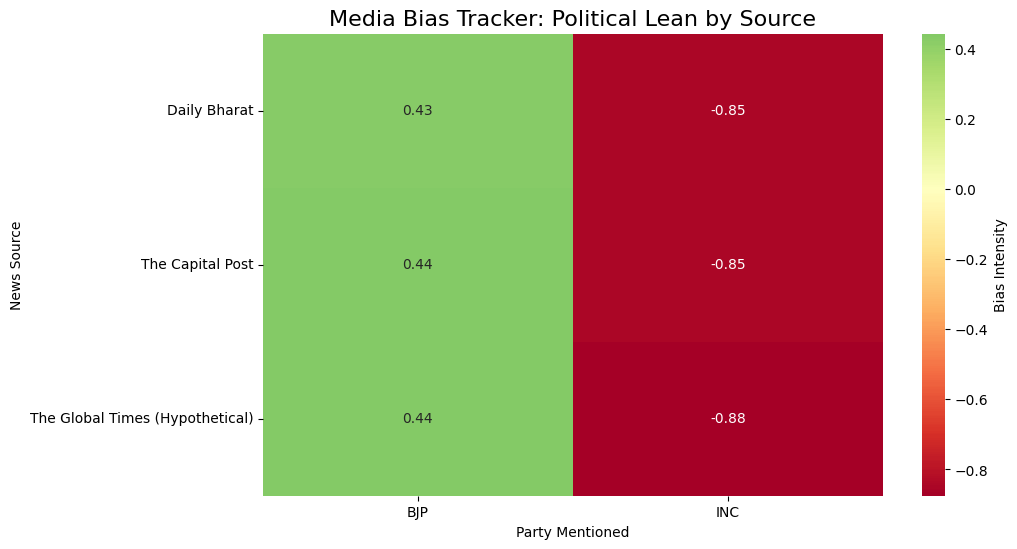

In [46]:
plt.figure(figsize=(10, 6))
sns.heatmap(bias_matrix, annot=True, cmap="RdYlGn", center=0, cbar_kws={'label': 'Bias Intensity'})
plt.title('Media Bias Tracker: Political Lean by Source', fontsize=16)
plt.xlabel('Party Mentioned')
plt.ylabel('News Source')
plt.show()

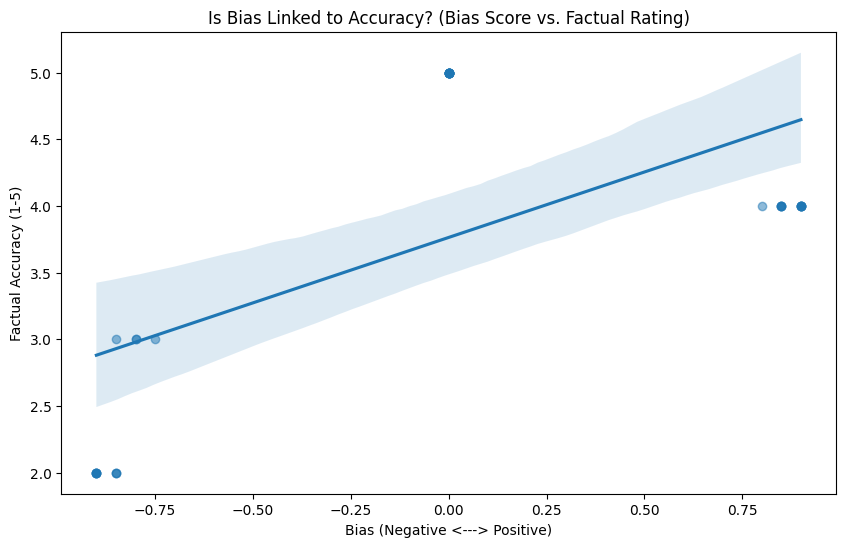

In [47]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='bias_score', y='factual_accuracy_rating', scatter_kws={'alpha':0.5})
plt.title('Is Bias Linked to Accuracy? (Bias Score vs. Factual Rating)')
plt.xlabel('Bias (Negative <---> Positive)')
plt.ylabel('Factual Accuracy (1-5)')
plt.show()

# More Easy to understand charts

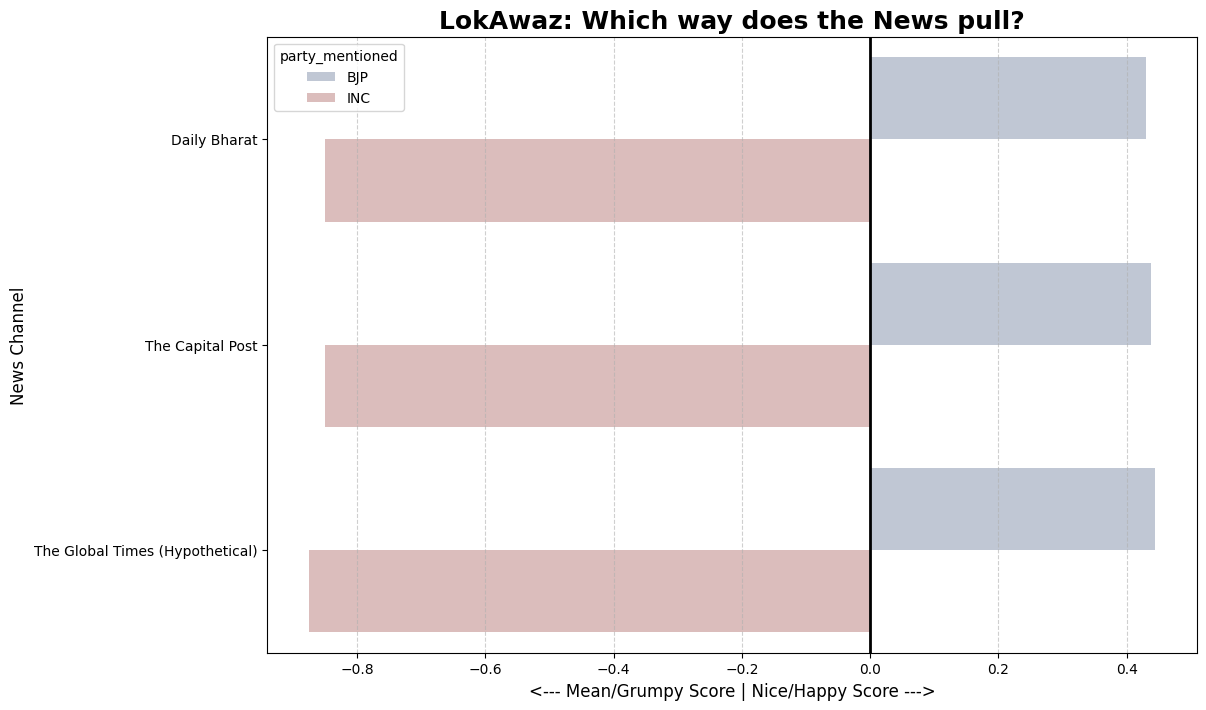

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare the data
df = pd.read_json('lokMBUBDATA.json')
bias_summary = df.groupby(['source', 'party_mentioned'])['bias_score'].mean().reset_index()

# 2. Create the Visual
plt.figure(figsize=(12, 8))
colors = ["#e74c3c" if x < 0 else "#2ecc71" for x in bias_summary['bias_score']]

# Use "vlag" or "RdYlGn" (Red-Yellow-Green)
sns.barplot(data=bias_summary, x='bias_score', y='source', hue='party_mentioned', palette="vlag")

# 3. Make it easy to read
plt.axvline(0, color='black', linewidth=2) # The "Fairness" Line
plt.title('LokAwaz: Which way does the News pull?', fontsize=18, fontweight='bold')
plt.xlabel('<--- Mean/Grumpy Score | Nice/Happy Score --->', fontsize=12)
plt.ylabel('News Channel', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()


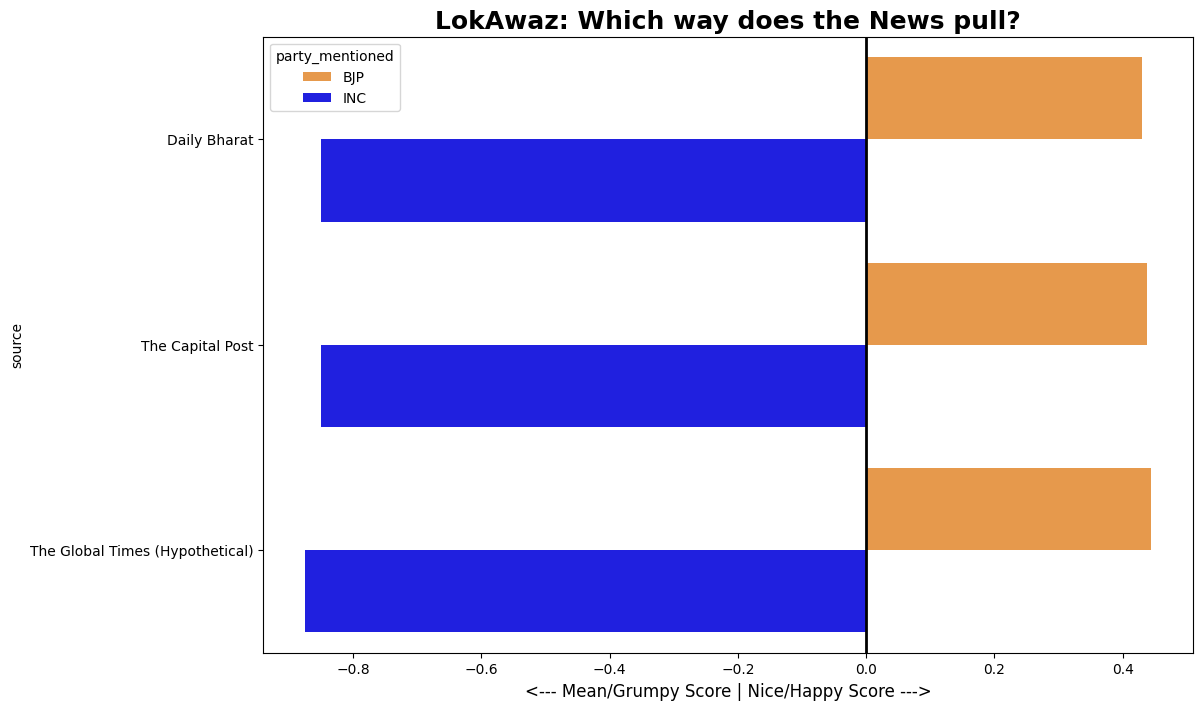

In [ ]:
custom_colors = {"BJP": "#FF9933", "INC": "#0000FF"}

plt.figure(figsize=(12, 8))
sns.barplot(
    data=bias_summary, 
    x='bias_score', 
    y='source', 
    hue='party_mentioned', 
    palette=custom_colors  # <--- This is the magic line
)

# 3. Add the "Fairness" line and titles again
plt.axvline(0, color='black', linewidth=2)
plt.title('LokAwaz: Which way does the News pull?', fontsize=18, fontweight='bold')
plt.xlabel('<--- Mean/Grumpy Score | Nice/Happy Score --->', fontsize=12)
plt.show()